## TD3 : Décomposition de série temporelle


1) Installer et importer les « librairies » `pandas` (as pd) et [`mistat`](https://pypi.org/project/mistat/), [`pingouin`](https://pypi.org/project/pingouin/) ainsi que les « librairies » dépendantes respectivement à l’aide des commandes `pip install` et `import`.


In [1]:
import sys
!{sys.executable} -m pip install mistat

  Obtaining dependency information for mistat from https://files.pythonhosted.org/packages/22/de/af941140ae086ac43db7085b8b441ecbe2b2a01d113d106b962431e9f3a4/mistat-0.1.17-py3-none-any.whl.metadata
  Obtaining dependency information for pyDOE3 from https://files.pythonhosted.org/packages/8b/6e/3b16b75e1e011f95109be5dcec3d1f1d5a8585e6c42b6c5bbb17852d66b2/pydoe3-1.6.2-py2.py3-none-any.whl.metadata
  Preparing metadata (setup.py) ... done
  Obtaining dependency information for pingouin from https://files.pythonhosted.org/packages/eb/56/6d3607f3a78aee1de8e5466f5171722c8e344266a12dc44ccb73d024b3b3/pingouin-0.5.5-py3-none-any.whl.metadata
  Obtaining dependency information for pandas-flavor from https://files.pythonhosted.org/packages/5d/e6/71ed4d95676098159b533c4a4c424cf453fec9614edaff1a0633fe228eef/pandas_flavor-0.7.0-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 44.6 MB/s eta 0:00:000m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.

In [2]:
import sys
!{sys.executable} -m pip install pingouin

In [3]:
# dataframe
import pandas as pd
# statistics library
import mistat
# statistical package for pandas
import pingouin

2) Importer les librairies `numpy` (as np) et `matplotlib.pyplot` (as plt) ainsi que `statsmodels.tsa` de `tsa.tools` et indiquer `import statsmodels.formula.api as smf`.

In [4]:
# numerical calculations
import numpy as np
# visualisation
import matplotlib.pyplot as plt
# time series
import statsmodels.tsa
import statsmodels.formula.api as smf

3) Créer un objet nommé dow1941 dans lequel vous allez stocker l’objet dow1941 de mistat à l’aide de la commande load_data et visualisez-le en faisant un graphe en nommant les axes des abscisses dow1941.index « jours ouvrés » et des ordonnées dow1941 « Cours du Dow Jones 1941 ».

In [5]:
# load data
dow1941 = mistat.load_data('DOW1941_DATE')
dow1941

,Date,Open,High,Low,Close,Volume
0,1941-01-02,131.1,131.9,130.4,130.6,59775
1,1941-01-03,130.6,132.2,130.2,132.0,57519
2,1941-01-04,132.0,133.1,132.0,132.4,94566
3,1941-01-06,132.4,133.7,132.4,132.8,81203
4,1941-01-07,132.8,133.5,132.2,133.0,59775
...,...,...,...,...,...,...
296,1941-12-26,106.7,107.9,105.9,107.0,159023
297,1941-12-27,107.0,108.2,106.2,107.5,155594
298,1941-12-29,107.5,108.9,106.4,107.6,330451
299,1941-12-30,107.6,112.0,107.5,111.3,288722


Text(0, 0.5, 'Cours du Dow Jones 1941')

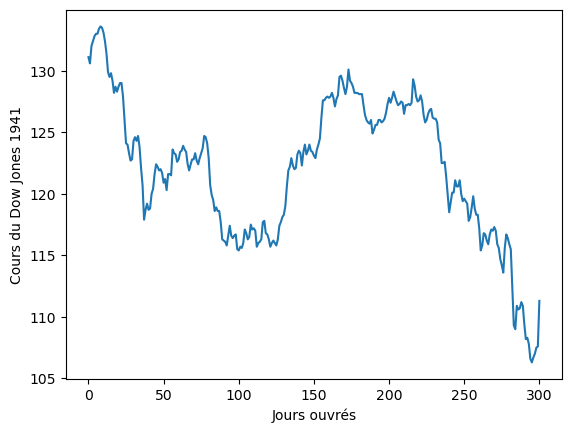

In [21]:
# visualisation
fig, ax = plt.subplots()
dow1941["Open"].plot()
ax.set_xlabel("Jours ouvrés")
ax.set_ylabel("Cours du Dow Jones 1941")


4) convertir l’objet `dow1941` en une série temporelle nommée `dow1941_ts` (ts comme time serie) à l’aide de la commande `pd.to_datetime` au format `%Y-%m-%d` de la façon suivante :


In [20]:
# convert Date column to Python datetime
dates = pd.to_datetime(dow1941['Date'], format='%Y-%m-%d')
# extract Open as a series
dow1941_ts = pd.Series(dow1941['Open'], name='Dow_Jones_Open')
# set dates as index
dow1941_ts.index = pd.DatetimeIndex(dates)
dow1941_ts.head()

Date
1941-01-02    131.1
1941-01-03    130.6
1941-01-04    132.0
1941-01-06    132.4
1941-01-07    132.8
Name: Dow_Jones_Open, dtype: float64

5) En utilisant `tsatools` de `statsmodels.tsa`, créer un objet `dow1941_df` à partir de `dow1941` en ayant ajouté un *trend* (tendance) à l’aide de la commande [`tsatools.add_trend`](https://www.statsmodels.org/devel/generated/statsmodels.tsa.tsatools.add_trend.html) comme suit :


In [13]:
# add trend 
from statsmodels import tsa
dow1941_df = tsa.tsatools.add_trend(dow1941_ts, trend='ct')
dow1941_df.head()

,Dow_Jones_Open,const,trend
Date,,,
1941-01-02,131.1,1.0,1.0
1941-01-03,130.6,1.0,2.0
1941-01-04,132.0,1.0,3.0
1941-01-06,132.4,1.0,4.0
1941-01-07,132.8,1.0,5.0


Le paramètre `trend = 'ct'` indique qu'on souhaite ajouter un trand constant et linéaire.

<div class="alert alert-block alert-info">
    <b>Tendance</b> (<i>trend</i>) est l'orientation long-terme de la série temporelle et peut être <i>croissante</i>, <i>décroissante</i> ou <i>horizontale</i>.
</div>

6) Ajuster la série temporelle à l’aide d’un modèle 1 linéraire (i.e. de type C1 x temps + C2) à l’aide de la commande [`smf.ols`](https://www.statsmodels.org/devel/generated/statsmodels.formula.api.ols.html) (*ols*: *ordinary least squares*). Que valent les constantes C1 et C2 ? Visualiser sur un même graphe la série temporelle et son ajustement linéaire. Pour cela, taper les commandes suivantes :


Intercept    62.964631
trend        -0.026070
const        62.964631
dtype: float64


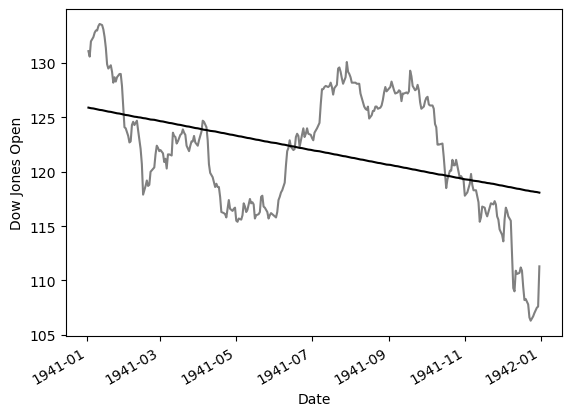

In [ ]:
# add trend
dow1941_df = tsa.tsatools.add_trend(dow1941_ts, trend='ct')
# create model_1
model_1 = smf.ols(formula='Dow_Jones_Open ~ trend + 1', data=dow1941_df).fit()
# print the model
print(model_1.params)

# visualisation
ax = dow1941_ts.plot(color='grey')
ax.set_xlabel('Time')
ax.set_ylabel('Dow Jones Open')
# use model
model_1.predict(dow1941_df).plot(ax=ax, color='black')
plt.show()

In [19]:
print(f'r2-adj: {model_1.rsquared_adj:.3f}')

r2-adj: 0.151


**Conclusion** :

7) Afficher l’indice de qualité de l’ajustement comme le R^2 ajusté à l’aide de la commande : `print(f'r2-adj: {model_1.rsquared_adj:.3f}')` et commenter le résultat obtenu.

<div class="alert alert-block alert-info">
Soit $n$ le nombre de points dans le jeu de données. Soient $y_1, y_2, ..., y_n$ les vraies valeurs présentes dans le jeu de données. Soient $\hat{y}_i$ les valeurs prédites par le modèle. 

La <i>somme des carrés des résidus</i> (<i>residual sum of squares</i>) est alors donnée par : $SS_{res} = \sum_i (y_i - \hat{y}_i)^2 = \sum_i e_i^2$. 

La somme totale des carrés (porportionnelle à la variance des données) est donnée par : $SS_{tot} = \sum_i (y_i - \bar{y})^2$ où $\bar{y} = \frac{1}{n}\sum_i^n y_i$.
    
<b>Coefficient de détermintation</b>, $R^2$ (<i>R squared</i>) est une mesure de l'adéquation d'un modèle :
$$R^2 = 1 - \frac{SS_{res}}{SS_tot}$$

En cas général, $R^2$ prend les valeurs dans l'intervalle de 0 à 1.
    
<i>Interprétation</i> : En régression, le coefficient de détermination $R^2$ est une mesure statistique du degré d'approximation des prédictions de régression par rapport aux points de données réels. Un $R^2$ de 1 indique que les prédictions de régression correspondent parfaitement aux données.
</div>

<div class="alert alert-block alert-info">
<b>Coefficient de détermintation ajusté</b> (<i>adjusted R squared</i>) est donné par :

$$R^2_{adj} = \bar{R}^2 = 1 - (1 - R^2)\frac{n - 1}{n - p - 1}$$

où $p$ est le nombre de variables explicatives du modèle. 
    
$R^2$ peut être interprété comme la variance du modèle, qui est influencée par la complexité du modèle. Un $R^2$ élevé indique une erreur de biais plus faible car le modèle peut mieux expliquer le changement de $Y$ avec les prédicteurs. Pour cette raison, nous faisons moins d'hypothèses (erronées), ce qui se traduit par une erreur de biais plus faible. Parallèlement, pour tenir compte de moins d'hypothèses, le modèle tend à être plus complexe. Sur la base du compromis biais-variance, une plus grande complexité entraînera une diminution du biais et une meilleure performance. Dans la formule de $R^2_{adj}$, le terme $(1 - R^2)$ sera plus faible avec une complexité élevée, ce qui se traduira par une performance plus élevée. 
    
Ainsi, le $R^2_{adj}$ tient compte du nombre de termes dans le modèle. Il est important de noter que sa valeur n'augmente que lorsque le nouveau terme améliore l'adéquation du modèle plus que ne le prévoit le hasard. La valeur du $R^2_{adj}$ diminue  lorsque le terme n'améliore pas suffisamment l'ajustement du modèle.
</div>


9) Refaire les questions 6, 7 et 8 avec des ajustements quadratiques et cubiques. Conclusions ?


Intercept    123.109424
trend          0.029768
trend_sq      -0.000185
dtype: float64


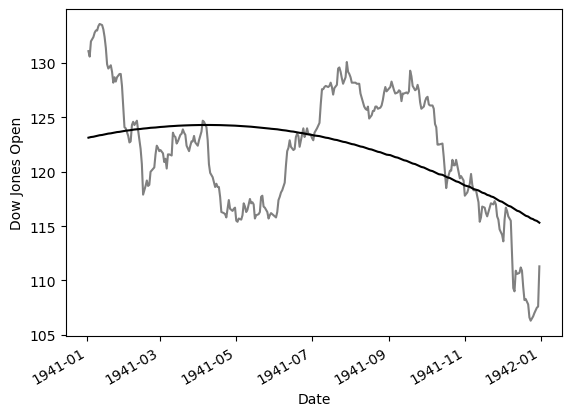

r2-adj: 0.195


In [71]:
# ajustement quadratique
# add trend
dow1941_df = tsa.tsatools.add_trend(dow1941_ts, trend='ct')
dow1941_df["trend_sq"] = dow1941_df["trend"]**2
# create model_1
model_2 = smf.ols(formula='Dow_Jones_Open ~ trend + trend_sq', data=dow1941_df).fit()
# print the model
print(model_2.params)

# visualisation
ax = dow1941_ts.plot(color='grey')
ax.set_xlabel('Time')
ax.set_ylabel('Dow Jones Open')
# use model
model_2.predict(dow1941_df).plot(ax=ax, color='black')
plt.show()

print(f'r2-adj: {model_2.rsquared_adj:.3f}')

Intercept    135.306337
trend         -0.450896
trend_sq       0.003788
trend_cu      -0.000009
dtype: float64


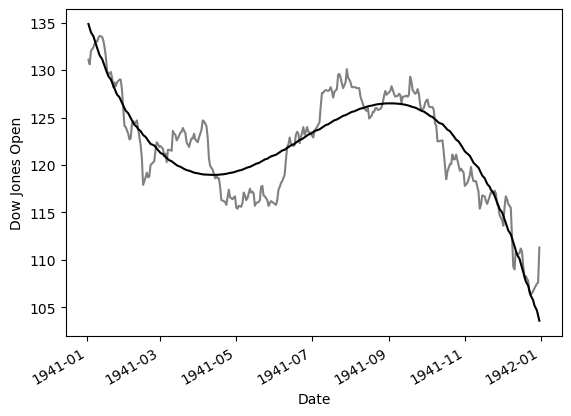

r2-adj: 0.809


In [ ]:
# ajustement cubique
# add trend
dow1941_df = tsa.tsatools.add_trend(dow1941_ts, trend='ct')
dow1941_df["trend_sq"] = dow1941_df["trend"]**2
dow1941_df["trend_cu"] = dow1941_df["trend"]**3

# create model_1
model_3 = smf.ols(formula='Dow_Jones_Open ~ trend + trend_sq + trend_cu', data=dow1941_df).fit()
# print the model
print(model_3.params)

# visualisation
ax = dow1941_ts.plot(color='grey')
ax.set_xlabel('Time')
ax.set_ylabel('Dow Jones Open')
# use model
model_3.predict(dow1941_df).plot(ax=ax, color='black')
plt.show()

print(f'r2-adj: {model_3.rsquared_adj:.3f}')

**Conclusion** :

Quelquefois, les données temporelles présentent une <b>saisonnalité</b>. L'étude de celle-ci permet de comprendre plus en profondeur le phénomène considéré.

<div class="alert alert-block alert-info">
<b>Saisonnalité</b> (<i>seasonality</i>) est la présence de patterns répétitifs à travers le temps, i.e. de variations qui se produisent à des intervalles réguliers spécifiques. Souvent on considère les intervalles inférieurs à l'année, tels qu'hebdomadaires, mensuels ou trimestriels.
</div>

10) Décomposition d'une série temporelle en $trend + saisonnalité + résidus$


10-1) Modèle additif ou multiplicatif ?

Importer la base de données `AirPassengers.csv` qui mesure le nombre mensuel de passagers aériens. Nous allons décomposer cette série statistique $X$ en une tendance $T$ et une saisonnalité $S$ (et des résidus $R$ non expliqués par le modèle).

Il existe deux type de modèles : 
- **les modèles additifs** : $X(t) = T(t) + S(t) + R(t)$ 
- **les modèles multiplicatifs** : $X(t) = T(t) \times S(t) \times R(t)$. 

Les deux modèles se distinguent par des amplitudes de la saisonnalité constantes dans le cas du modèle additif (autrement dit, mes variatopns sont "stables" autour de la tendance) et des amplitudes de la saisonnalité proportionnelles à $X$ dans le second (i.e. l'amplitude des variations varie). 

Notez que, le modèle multiplicatif puet être ramené à un modèle additif en passant par $log$ : $ln(X) = ln(T) + ln(S) + ln(R)$. 

Ainsi, pour déterminer si le modèle est additif ou multiplicatif, visualisez $X$ et $ln(X)$. Conclure.

In [45]:
# load data 
passagers = pd.read_csv("AirPassengers.csv")
passagers

,t,Airpass
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


<Axes: xlabel='t'>

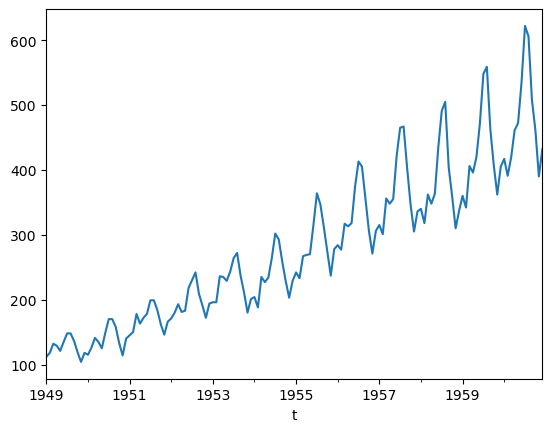

In [54]:
# visualisation
dates = pd.to_datetime(passagers["t"], format='%Y-%d-%d')

# extract Open as a series
passagers_ts = pd.Series(passagers['Airpass'], name='Airpass_pass')
# set dates as index
passagers_ts.index = pd.DatetimeIndex(dates)
passagers_ts.head()

passagers_ts.plot()

Le modèle semble multiplicatif.

11-2) quelle période pour la saisonnalité ?

Déterminer graphiquement la période de la saisonnalité de X.

11-3) Décomposer la série X à l'aide de la librairie `statsmodels.tsa.seasonal` et de sa fonction [`seasonal_decompose`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html). Conclure.

t
1949-01-01   -24.748737
1949-02-01   -36.188131
1949-03-01    -2.241162
1949-04-01    -8.036616
1949-05-01    -4.506313
                ...    
1960-08-01    62.823232
1960-09-01    16.520202
1960-10-01   -20.642677
1960-11-01   -53.593434
1960-12-01   -28.619949
Name: seasonal, Length: 144, dtype: float64


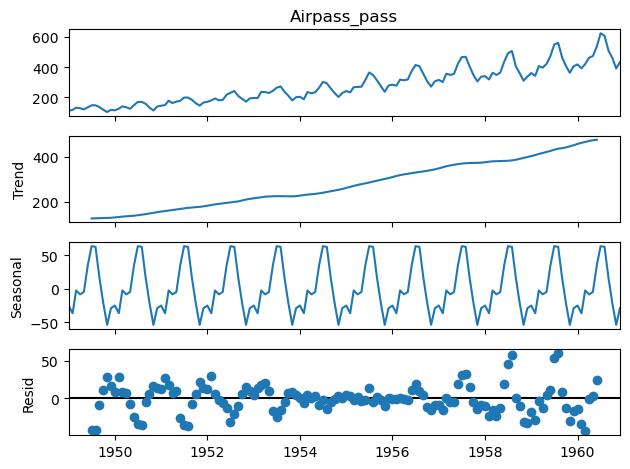

In [64]:
# modèle additif
from statsmodels.tsa.seasonal import seasonal_decompose
s = seasonal_decompose(passagers_ts, model="additive")
s.plot()
print(s.seasonal)


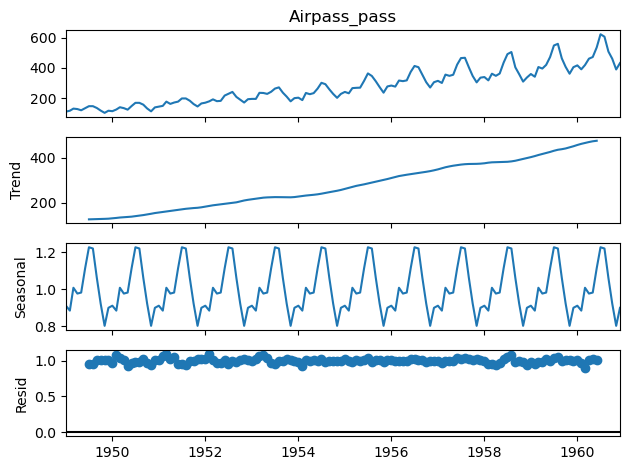

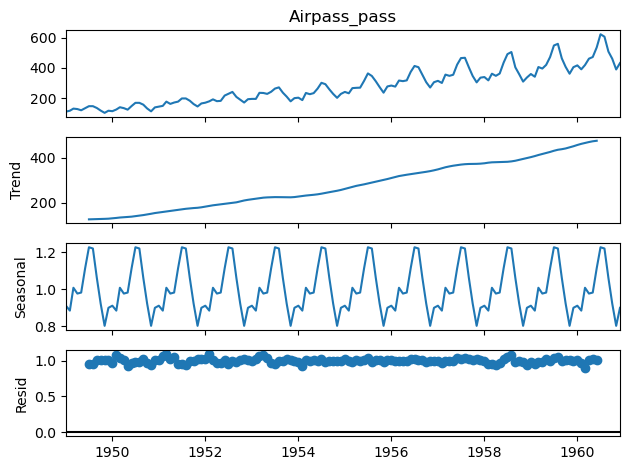

In [61]:
# modèle multiplicatif
s = seasonal_decompose(passagers_ts, model="multiplicative")
s.plot()

11-4) Décomposer la série ln(X) à l'aide de la librairie statsmodels.tsa.seasonal et de sa fonction seasonal_decompose. Quel paramètre devez-vous changer par rapport à la question précédente ? Conclure.

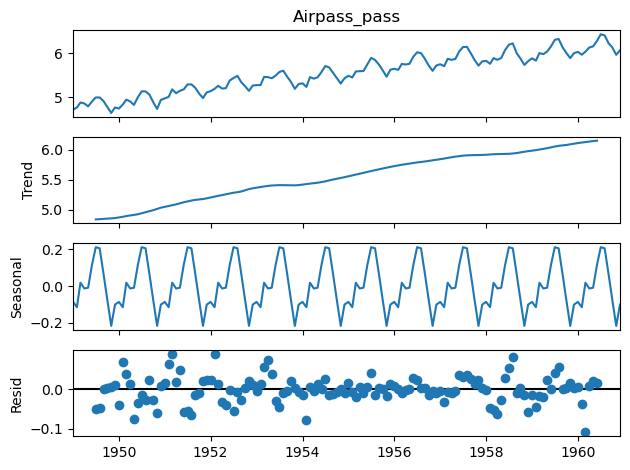

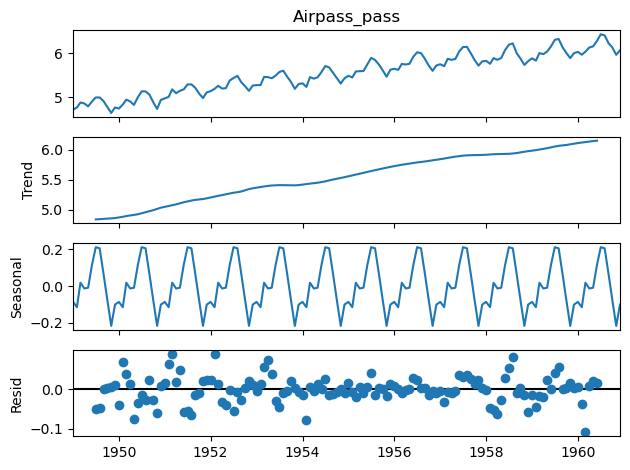

In [69]:
passagers_ln = np.log(passagers_ts)
s = seasonal_decompose(passagers_ln, model="additive")
s.plot()


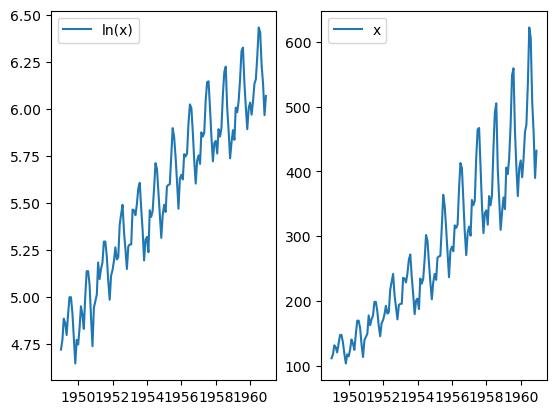

In [ ]:
# visualiser X et ln X
fig, ax = plt.subplots(1, 2)
ax[0].plot(passagers_ln, label="ln(x)")
ax[1].plot(passagers_ts, label="x")
ax[0].legend()
ax[1].legend()